In [1]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
from agnpy.synchrotron.BaseSynchrotron import Synchrotron
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
mec2 = mec2.to('eV')
import matplotlib.pyplot as plt

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [2]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o =  (3.63 * 1e-5 * u.T).to(u.G)
u_B = ((B_to_cgs(B_o)**2)/(8*np.pi)).to('erg cm-3')
R_o = 7.32 * 1e15 * u.cm
W_j = 7.63 * 1e36* u.W
L = (100 * u.pc)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = (5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_c = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
n_e = ExpCutoffPowerLaw(k = 1 , mass=m_e, p=p, gamma_min = 0.1*gamma_minimum, gamma_max= 100*gamma_c, gamma_c= gamma_c )


In [3]:
jet = Cone.from_jet_power(W_j = W_j , B_o = B_o , L = L, n_e = n_e, theta = theta_open, Gamma=Gamma,x_size=500,gamma_e_size=1000, z =z)
jet.set_delta_D(Gamma, theta_s)

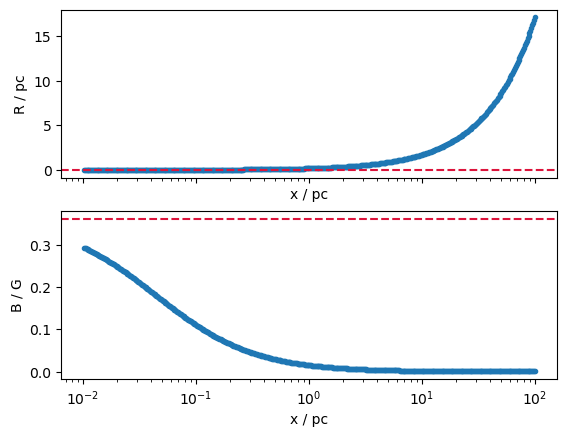

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].semilogx(
    jet.x.to_value("pc"),
    jet.R_x.to_value("pc"),
    marker=".",
    color="C0"
)
ax[0].axhline(
    jet.R_o.to_value("pc"),
    ls="--",
    color="crimson"
)
ax[0].set_xlabel("x / pc")
ax[0].set_ylabel("R / pc")

ax[1].semilogx(
    jet.x.to_value("pc"),
    jet.B_x,
    marker=".",
    color="C0"
)
ax[1].axhline(
    jet.B_o.value,
    ls="--",
    color="crimson"
)
ax[1].set_xlabel("x / pc")
ax[1].set_ylabel("B / G")
plt.show()


# Plots 

In [5]:
coordinates = [
    (585945.3915069195, 6.65905647933771e+45),
    (1180320.6356517298, 3.6753441641809446e+45),
    (2421029.04673618, 1.8950291465743076e+45),
    (5861381.645140285, 8.435148160601475e+44),
    (14454397.70745931, 3.481142923888426e+44),
    (23768402.866248783, 2.075324880373661e+44),
    (46989410.860521704, 1.1534180805525196e+44),
    (147231250.24327165, 3.8169973137017866e+43),
    (325087297.38543606, 1.693846972334023e+43),
    (831763771.1026742, 6.485157528062233e+42),
    (1614358556.8264935, 2.865619626947542e+42),
    (3076096814.7407174, 1.1725707943387419e+42),
    (5445026528.424242, 4.4349366153056454e+41),
    (10964781961.43192, 7.858944800779638e+40),
    (18030177408.59577, 1.2817831835790027e+40),
    (28575905433.749672, 1.2244668158998756e+39),
    (39084089579.24041, 1.164019524379192e+38),
    (59703528658.38415, 2.0753248803736612e+36),
    (89536476554.96011, 4.373153302721358e+33),
    (109647819614.31963, 7.740013565615246e+31),
    (129419584144.9997, 1.4766294411828247e+30)
]
x_data, y_data = zip(*coordinates)

In [6]:
jet.N_e_xg

<Quantity [[1.82584578e+36, 1.72694977e+36, 1.63341029e+36, ...,
            1.92754227e-18, 1.30899635e-19, 7.81536678e-21],
           [1.83867645e+36, 1.73908547e+36, 1.64488867e+36, ...,
            1.76414978e-20, 1.15176401e-21, 6.30531872e-23],
           [1.85179232e+36, 1.75149093e+36, 1.65662219e+36, ...,
            1.58081945e-22, 9.90400847e-24, 4.99525973e-25],
           ...,
           [2.79920294e+39, 1.34574863e+39, 6.26064241e+38, ...,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
           [1.86151426e+39, 8.75679487e+38, 3.98555274e+38, ...,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
           [1.22022775e+39, 5.61601370e+38, 2.50047113e+38, ...,
            0.00000000e+00, 0.00000000e+00, 0.00000000e+00]] 1 / cm>

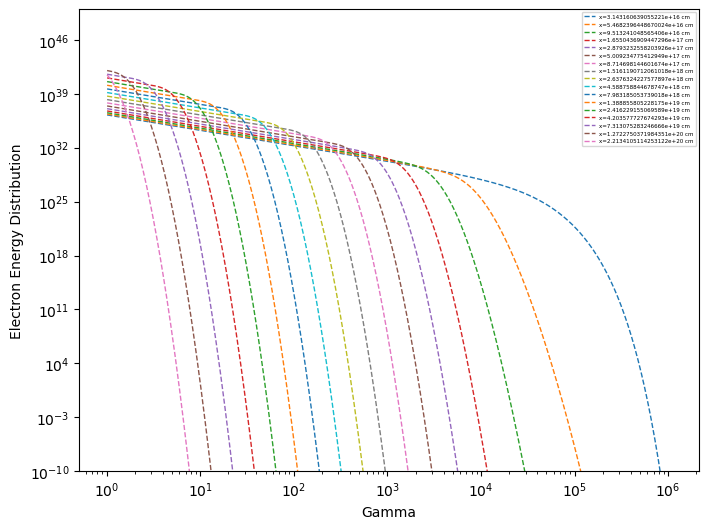

In [7]:
plt.figure(figsize=(8,6))
for i, _n_e_g in enumerate(jet.N_e_xg[::30]):
    plt.loglog(jet.gamma_e, _n_e_g, label=f"x={jet.x[30*i]}",linestyle='dashed',lw=1)
plt.xlabel('Gamma')
plt.ylabel('Electron Energy Distribution')
plt.legend(fontsize=4)
plt.ylim(1e-10,1e50)
plt.show()

In [8]:
(10000000*u.h).cgs*c.cgs

<Quantity 1.07925285e+21 cm>

In [ ]:
nu_obs = np.logspace(3, 25, 1000) * u.Hz
syn= Synchrotron(jet)
flux = syn.flux_obs(nu_obs)

In [9]:
syn.evaluate_attenuation()
sed_x_nossa = syn.sed_spatial(nu_obs) * jet.x[:,None]
sed_x_ssa = syn.sed_spatial(nu_obs,ssa=True) *jet.x[:,None]

/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: overflow encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/BaseSynchrotron.py:36: RuntimeWarning: divide by zero encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/usharma/Documents/GitHub/agnpy/agnpy/synchrotron/BaseSynchrotron.py:36: RuntimeWarning: overflow encountered in divide
  u = 0.5 + np.exp(-tau) / tau - (1 - np.exp(-tau)) / np.power(tau, 2)
/Users/

In [10]:
sed_nossa= syn.sed_flux(nu_obs, ssa=False)

In [11]:
syn.evaluate_attenuation()
sed_ssa= syn.sed_flux(nu_obs, ssa=True)

In [12]:
nu_peak= syn.nu_peak()

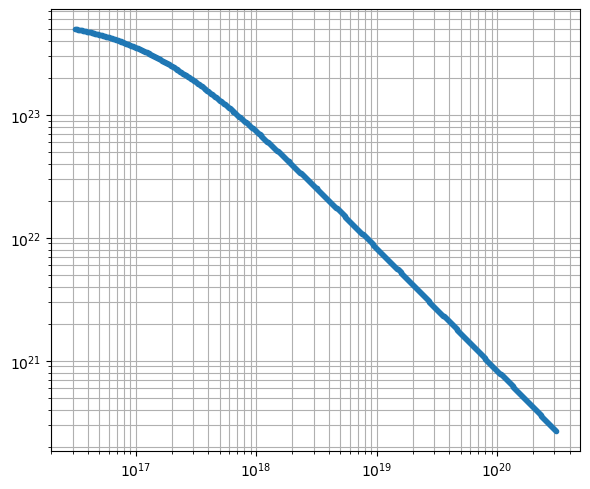

In [13]:
plt.figure(figsize=(6,5))
plt.loglog(jet.x, np.trapz(nu_peak,jet.gamma_e,axis=1), marker='.')
plt.grid(True, which='both')
#plt.ylim(1e-15, 1e-8)
#plt.xlim(1,1e20)
#plt.legend()
plt.tight_layout()
plt.show()

In [30]:
def Z(eta):
    """Synchrotron kernel approximation (Aharonian 2010, Eq. D7)."""
    term_1_num = 1.808 * np.power(eta, 1 / 3)
    term_1_denom = np.sqrt(1 + 3.4 * np.power(eta, 2 / 3))
    term_2_num = 1 + 2.21 * np.power(eta, 2 / 3) + 0.347 * np.power(eta, 4 / 3)
    term_2_denom = 1 + 1.353 * np.power(eta, 2 / 3) + 0.217 * np.power(eta, 4 / 3)
    return term_1_num / term_1_denom * term_2_num / term_2_denom * np.exp(-eta)

In [12]:
Z_eta[0,0,:]

<Quantity [6.23695964e-002, 6.34304409e-002, 6.45092462e-002,
           6.56063119e-002, 6.67219423e-002, 6.78564467e-002,
           6.90101393e-002, 7.01833391e-002, 7.13763702e-002,
           7.25895617e-002, 7.38232480e-002, 7.50777684e-002,
           7.63534678e-002, 7.76506963e-002, 7.89698092e-002,
           8.03111675e-002, 8.16751376e-002, 8.30620913e-002,
           8.44724064e-002, 8.59064660e-002, 8.73646592e-002,
           8.88473806e-002, 9.03550309e-002, 9.18880167e-002,
           9.34467502e-002, 9.50316501e-002, 9.66431407e-002,
           9.82816526e-002, 9.99476225e-002, 1.01641493e-001,
           1.03363714e-001, 1.05114739e-001, 1.06895031e-001,
           1.08705058e-001, 1.10545293e-001, 1.12416218e-001,
           1.14318318e-001, 1.16252086e-001, 1.18218024e-001,
           1.20216635e-001, 1.22248434e-001, 1.24313937e-001,
           1.26413670e-001, 1.28548163e-001, 1.30717956e-001,
           1.32923590e-001, 1.35165615e-001, 1.37444589e-001,
        

# SED

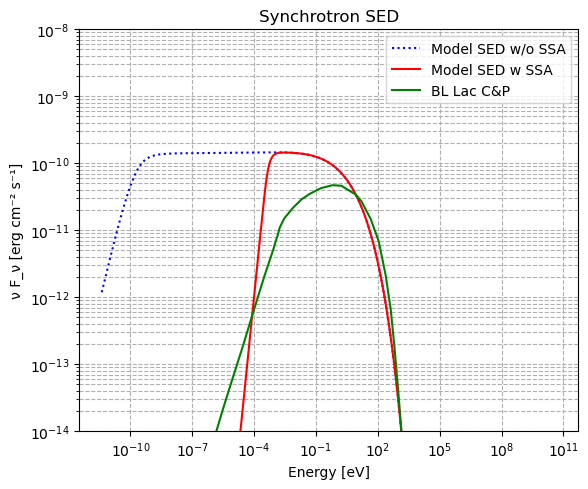

In [14]:
# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]

# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_nossa, color='blue', linestyle='dotted', label='Model SED w/o SSA')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', linestyle='solid', label='Model SED w SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_blob, color='black', linestyle='dotted', label='Model SED w Blob')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-8)
#plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
jet.x

<Quantity [3.14316064e+16, 3.20171455e+16, 3.26135926e+16, 3.32211509e+16,
           3.38400274e+16, 3.44704329e+16, 3.51125823e+16, 3.57666942e+16,
           3.64329916e+16, 3.71117015e+16, 3.78030550e+16, 3.85072877e+16,
           3.92246396e+16, 3.99553550e+16, 4.06996830e+16, 4.14578770e+16,
           4.22301953e+16, 4.30169012e+16, 4.38182627e+16, 4.46345527e+16,
           4.54660493e+16, 4.63130359e+16, 4.71758010e+16, 4.80546385e+16,
           4.89498479e+16, 4.98617342e+16, 5.07906079e+16, 5.17367857e+16,
           5.27005897e+16, 5.36823485e+16, 5.46823964e+16, 5.57010743e+16,
           5.67387290e+16, 5.77957143e+16, 5.88723901e+16, 5.99691233e+16,
           6.10862875e+16, 6.22242633e+16, 6.33834385e+16, 6.45642080e+16,
           6.57669740e+16, 6.69921463e+16, 6.82401423e+16, 6.95113873e+16,
           7.08063142e+16, 7.21253644e+16, 7.34689871e+16, 7.48376401e+16,
           7.62317898e+16, 7.76519111e+16, 7.90984878e+16, 8.05720127e+16,
           8.20729879e+16

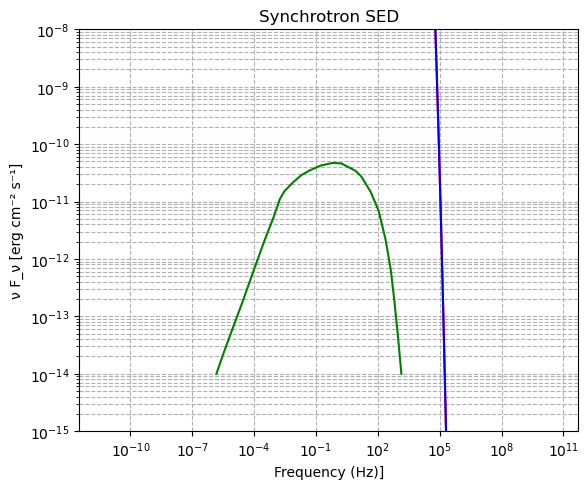

In [16]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs.to(u.eV, equivalencies=u.spectral())), np.trapz(sed_x_nossa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w/o SSA')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle='solid', color='blue',label='Model SED w SSA')
plt.loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
plt.xlabel("Frequency (Hz)]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-15, 1e-8)
#plt.xlim(1,1e20)
#plt.legend()
plt.tight_layout()
plt.show()

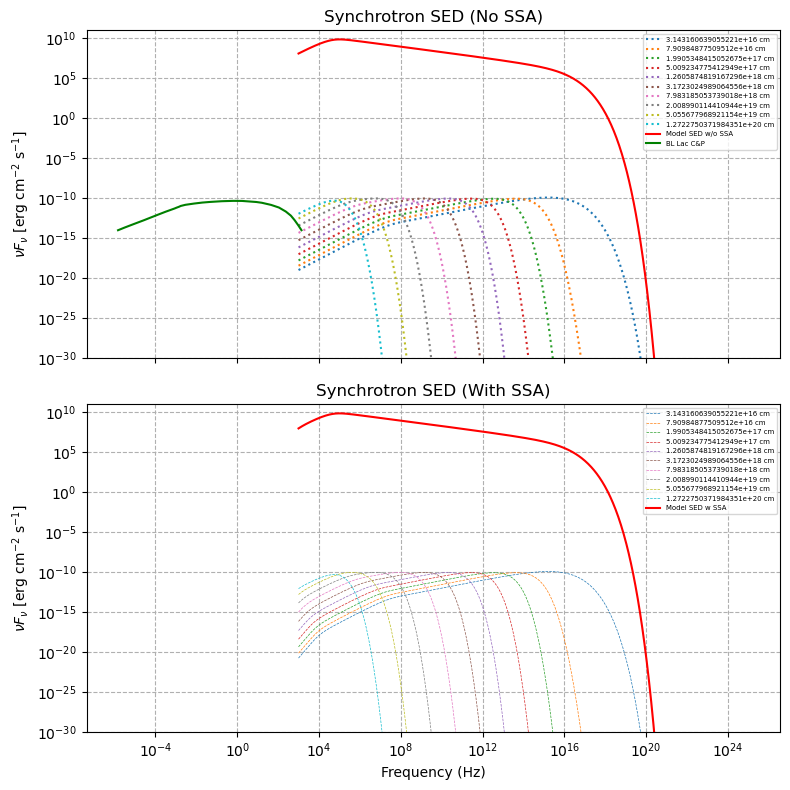

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1, figsize=(8, 8), sharex=True)

# -------------------------
# Top: without SSA
# -------------------------
for i, sed in enumerate(sed_x_nossa[::50]):
    axes[0].loglog(nu_obs, sed, linestyle='dotted',label = jet.x[50*i])
axes[0].loglog(nu_obs, np.trapz(sed_x_nossa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w/o SSA')
axes[0].loglog(x_sorted, y_sorted, linestyle='solid', color='green',label='BL Lac C&P')
axes[0].set_title("Synchrotron SED (No SSA)")
axes[0].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[0].grid(True, which='both', ls='--')
axes[0].set_ylim(1e-30, 1e11)
axes[0].legend(fontsize=5)

# -------------------------
# Bottom: with SSA
# -------------------------
for i, sed in enumerate(sed_x_ssa[::50]):
    axes[1].loglog(nu_obs, sed, linestyle='dashed', lw=0.5,label = jet.x[50*i])
axes[1].loglog((nu_obs), np.trapz(sed_x_ssa,jet.x,axis = 0), linestyle='solid', color='red',label='Model SED w SSA')
axes[1].set_title("Synchrotron SED (With SSA)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel(r"$\nu F_\nu$ [erg cm$^{-2}$ s$^{-1}$]")
axes[1].grid(True, which='both', ls='--')
axes[1].set_ylim(1e-30, 1e11)
axes[1].legend(fontsize=5)
plt.tight_layout()
plt.show()

In [20]:
np.trapz(jet.B_x[:,None]*jet.N_e_xg[:,:],jet.gamma_e,axis=1)

<Quantity [5.45306020e+35, 5.47216870e+35, 5.49163304e+35, 5.51145985e+35,
           5.53165587e+35, 5.55222798e+35, 5.57318317e+35, 5.59452859e+35,
           5.61627149e+35, 5.63841926e+35, 5.66097946e+35, 5.68395975e+35,
           5.70736795e+35, 5.73121203e+35, 5.75550010e+35, 5.78024043e+35,
           5.80544142e+35, 5.83111166e+35, 5.85725988e+35, 5.88389497e+35,
           5.91102600e+35, 5.93866218e+35, 5.96681294e+35, 5.99548783e+35,
           6.02469661e+35, 6.05444923e+35, 6.08475579e+35, 6.11562661e+35,
           6.14707218e+35, 6.17910320e+35, 6.21173057e+35, 6.24496537e+35,
           6.27881892e+35, 6.31330271e+35, 6.34842848e+35, 6.38420818e+35,
           6.42065396e+35, 6.45777822e+35, 6.49559358e+35, 6.53411290e+35,
           6.57334927e+35, 6.61331602e+35, 6.65402675e+35, 6.69549530e+35,
           6.73773575e+35, 6.78076248e+35, 6.82459008e+35, 6.86923348e+35,
           6.91470783e+35, 6.96102859e+35, 7.00821150e+35, 7.05627259e+35,
           7.10522819e+35

In [ ]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(jet.x, jet.B_x, marker='.')
plt.grid(True, which='both')
#plt.ylim(1e-15, 1e-8)
#plt.xlim(1,1e20)
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog(jet.x, jet.B_x,marker=".", ls="")
plt.grid(True, which='both', ls='--')
#plt.xlim(1e15, 1e16)
#plt.ylim(1e-5,1)
#plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
jet.x[1:20]

In [ ]:
plt.plot(jet.x, jet.R_x/jet.x, marker=".", ls="")
plt.show()

In [ ]:
x_test = np.linspace(20, 100, 50)
plt.loglog(x_test, 3*x_test)
plt.show()